# Google SERPS Analysis

Find out which metrics affect Google SERPs ranking.

## Specific questions

1. Does about_text get reused in:
   - seo_title
   - meta_description
2. Do SERP fields reuse leading substrings of:
   - about text
   - README title
   - Intro paragraphs
3. Does Google fall back to:
   - username/repo for SEO Title when no usable text exists?

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

merged = pd.read_csv("../data/merged_data.csv")
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 38 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_reponame   455 non-null    object
 1   search_phrase   455 non-null    object
 2   explore_rank    455 non-null    int64 
 3   google_rank     455 non-null    int64 
 4   source          455 non-null    object
 5   1st_el          455 non-null    object
 6   2nd_el          455 non-null    object
 7   3rd_el          455 non-null    object
 8   h1_ct           455 non-null    int64 
 9   h2_ct           455 non-null    int64 
 10  h3_ct           455 non-null    int64 
 11  toc             455 non-null    int64 
 12  images          455 non-null    int64 
 13  alt_text_ct     455 non-null    int64 
 14  code_blocks     455 non-null    int64 
 15  internal_links  455 non-null    int64 
 16  external_links  455 non-null    int64 
 17  live_link       455 non-null    int64 
 18  watchers  

### Calculations

Calculate charcter lengths for:

- About Text
- SEO Title
- Meta Description
- Title Text

> **NOTE**: I _may_ need to get the "intro" paragraph text (or other text elements) 

In [11]:
merged['about_len'] = merged['about_text'].str.len()
merged['seo_title_len'] = merged['seo_title'].str.len()
merged['meta_desc_len'] = merged['meta_desc'].str.len()
merged['title_text_len'] = merged['title_text'].str.len()

I set the `about_text` to "-" if the repo did not have any About text. 

I set the `seo_title` to "-" for all GitHub Explore records that were not part of repos found in Google SERPs (same for `meta_desc`). 

So here I filter those records out so that I am only looking at Google SERPS records (though I could have used the `source` field) where the repo has about text:

In [12]:
for n in [25, 40, 60]:
    merged[f'about_seo_match_{n}'] = (
        merged['about_text'].str[:n] == merged['seo_title'].str[:n]
    )

In [13]:
for n in [25, 40, 60]:
    merged[f'seo_h1_match_{n}'] = (
        merged['seo_title'].str[:n] == merged['title_text'].str[:n]
    )

In [14]:
for n in [25, 40, 60]:
    merged[f'about_meta_match_{n}'] = (
        merged['about_text'].str[:n] == merged['meta_desc'].str[:n]
    )

In [17]:
# Is df_about_seo a bad name?
df_about_seo = merged[(merged['about_len'] > 1) & (merged['seo_title_len'] > 1)].copy()
df_about_seo

,user_reponame,search_phrase,explore_rank,google_rank,source,1st_el,2nd_el,3rd_el,h1_ct,h2_ct,...,title_text_len,about_seo_match_25,about_seo_match_40,about_seo_match_60,seo_h1_match_25,seo_h1_match_40,seo_h1_match_60,about_meta_match_25,about_meta_match_40,about_meta_match_60
1,abeeken/api-starter,node rest api starter github,0,10,google_serp_github,h1,p,p,1,0,...,11,True,True,True,False,False,False,True,True,False
5,agude/Jupyter-Notebook-Template-Library,jupyter notebook template,15,36,google_serp,h2,h1,p,1,1,...,39,False,False,False,True,True,True,True,True,False
6,ahotko/c-sharp-code-examples,c# code snippets github,12,2,google_serp_github,h1,p,h2,1,2,...,36,False,False,False,False,False,False,False,False,False
11,alexjoverm/typescript-library-starter,typescript starter project github,0,9,google_serp_github,h1,p,pre,1,3,...,26,False,False,False,False,False,False,True,True,True
13,amin-abbasi/typescript-boilerplate,typescript boilerplate,0,10,google_serp,h1,p,h2,1,1,...,25,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,xxx87/node-api-template,node api template,0,27,google_serp,h1,h4,pre,1,0,...,26,False,False,False,False,False,False,True,False,False
446,Yasir-Rafique/rest-api-starter,node rest api starter github,0,10,google_serp_github,h2,p,p,0,7,...,16,False,False,False,False,False,False,False,False,False
450,YounesseElkars/Express-Prisma-TypeScript,typescript express api example github,0,5,google_serp_github,h1,h2,p,1,7,...,46,False,False,False,True,True,True,False,False,False
451,youssefbennour/AspNetCore.Starter,asp.net core starter project,0,5,google_serp,h1,p,p,1,9,...,29,False,False,False,False,False,False,False,False,False


In [19]:
df_about_seo['has_slash'] = df_about_seo['seo_title'].str.contains('/')
df_about_seo['has_slash'].value_counts()

has_slash
True     198
False     44
Name: count, dtype: int64

The following chart goes against what I would think ranks higher in Google.

Does have x's more False than true matter? Where False = an seo title that is username/reponame

<Axes: xlabel='has_slash', ylabel='google_rank'>

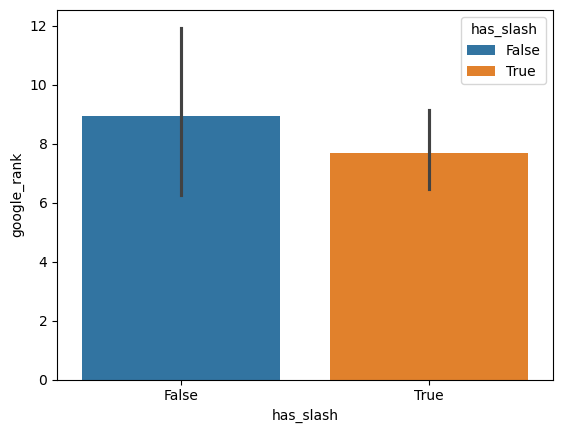

In [20]:
sns.barplot(data=df_about_seo, x='has_slash', y='google_rank', hue='has_slash')

<Axes: xlabel='has_slash', ylabel='google_rank'>

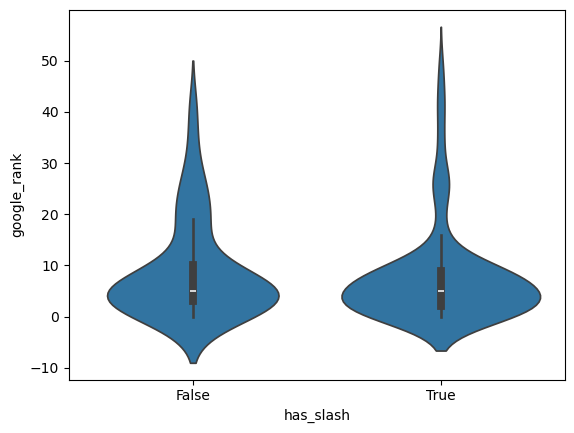

In [21]:
# How do I interpret this?
sns.violinplot(data=df_about_seo, x='has_slash', y='google_rank')

<Axes: xlabel='has_slash', ylabel='google_rank'>

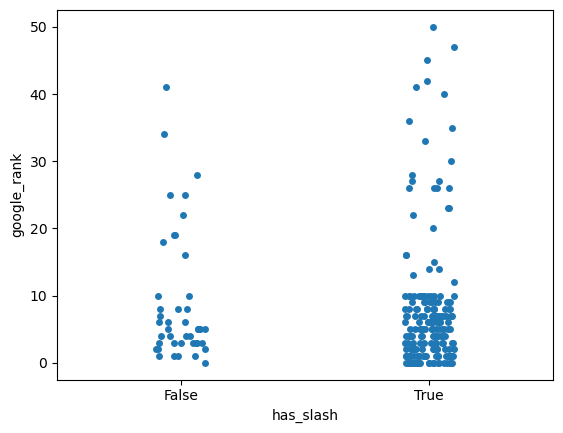

In [22]:
sns.stripplot(data=df_about_seo, x='has_slash', y='google_rank', jitter=True)

Does the following indicate that a better title text rank higher?

<Axes: xlabel='title_text_len', ylabel='google_rank'>

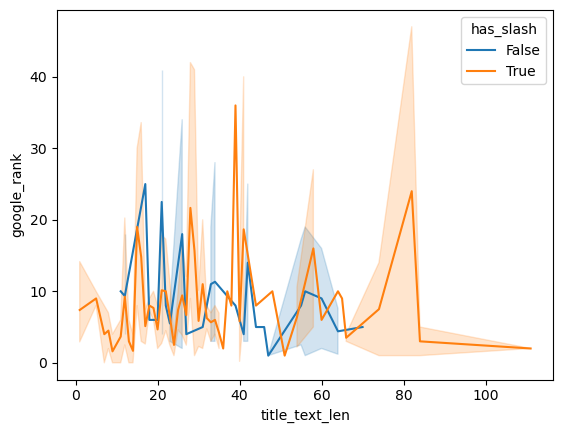

In [23]:
sns.lineplot(
    data=df_about_seo,
    x='title_text_len',
    y='google_rank',
    hue='has_slash',
    estimator='mean'
)

<Axes: xlabel='has_slash', ylabel='google_rank'>

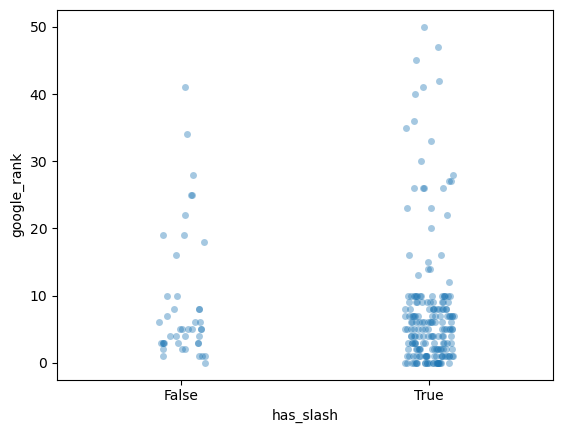

In [24]:
sns.stripplot(
    data=df_about_seo,
    x='has_slash',
    y='google_rank',
    jitter=True,
    alpha=0.4
)

<Axes: xlabel='google_rank', ylabel='has_slash'>

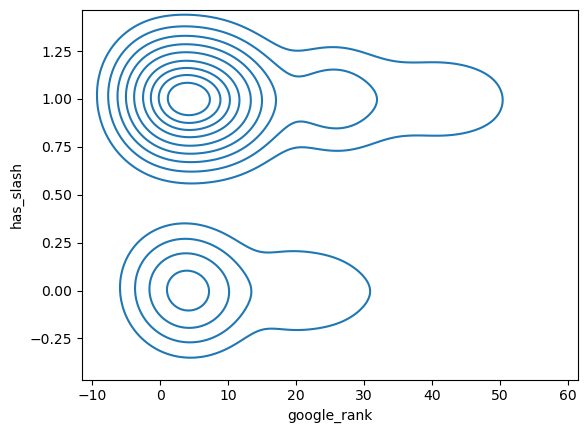

In [25]:
sns.kdeplot(
    data=df_about_seo,
    x='google_rank',
    y='has_slash',
    common_norm=False
)

<Axes: xlabel='google_rank', ylabel='Density'>

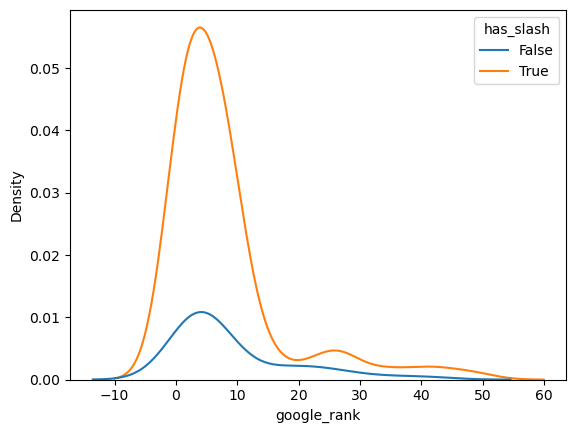

In [26]:
sns.kdeplot(
    data=df_about_seo,
    x='google_rank',
    hue='has_slash'
)

C:\Users\pc\anaconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


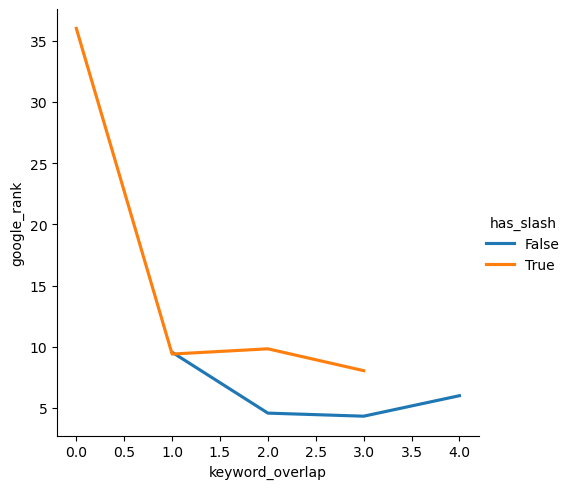

In [27]:
df_about_seo['seo_title_clean'] = df_about_seo['seo_title'].str.lower()

def keyword_overlap(row):
    title_words = set(row['seo_title_clean'].split())
    query_words = set(row['search_phrase'].split())
    return len(title_words.intersection(query_words))

df_about_seo['keyword_overlap'] = df_about_seo.apply(keyword_overlap, axis=1)

sns.lmplot(
    data=df_about_seo,
    x='keyword_overlap',
    y='google_rank',
    hue='has_slash',
    lowess=True,
    scatter=False
)

<Axes: xlabel='keyword_overlap', ylabel='google_rank'>

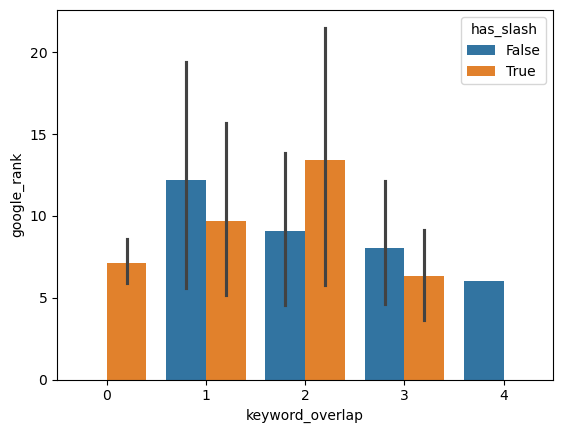

In [28]:
sns.barplot(
    data=df_about_seo,
    x='keyword_overlap',
    y='google_rank',
    hue='has_slash'
)